# Notebook 11a — Segmentación mediante clustering K-Means

## Objetivo

Aplicar el algoritmo K-Means para segmentar la cartera activa de clientes de Selmark en grupos comportamentalmente homogéneos. Este notebook implementa la primera parte del Capítulo 5 del TFG y abarca: preparación de los datos, análisis de componentes principales, determinación del número óptimo de clusters mediante cuatro métricas combinadas, aplicación del algoritmo K-Means sobre las componentes principales y comparativa metodológica con clustering jerárquico. La caracterización detallada de los segmentos obtenidos, incluyendo el cálculo de índices de afinidad y el análisis de importancia de variables mediante Random Forest, se desarrolla en el notebook 11b.

## Decisiones metodológicas

El análisis se construye sobre la base de las decisiones adoptadas tras el cierre del Capítulo 4. En primer lugar, el clustering se aplicará exclusivamente sobre los 3.084 clientes con actividad económica documentada en el cuatrienio 2022-2025, excluyendo las tres cuentas técnicas (REGO, HERREROS y ECI) y los clientes sin actividad económica. En segundo lugar, las variables de entrada serán ocho indicadores conductuales y no sociodemográficas, decisión fundamentada en los hallazgos del notebook 09b donde se demostró que la correlación renta-facturación es estadísticamente nula y los perfiles MOSAIC presentan ticket medio homogéneo. En tercer lugar, se aplicará transformación logarítmica a las variables económicas asimétricas y escalado robusto basado en mediana e IQR.

## Selección final de variables: validación empírica

La lista inicial de variables candidatas incluía nueve indicadores conductuales. Sin embargo, la matriz de correlaciones de Spearman reveló que la variable `facturacion_combinada` presentaba una correlación de +0,82 con `meses_activo`, sugiriendo redundancia informacional entre ambas. Para decidir empíricamente si esta redundancia afectaba a la calidad del clustering, se realizó un análisis comparativo en el notebook auxiliar `11a_experimentos.ipynb` que probó cuatro configuraciones: el baseline con las 9 variables, k=5 (en lugar de k=6), eliminación de `facturacion_combinada` (8 variables), y sustitución de `RobustScaler` por `StandardScaler`.

Los resultados validaron empíricamente la elección de k=6 y RobustScaler (ambas alternativas empeoraban claramente todas las métricas), pero mostraron que la eliminación de `facturacion_combinada` mejoraba el Adjusted Rand Index entre K-Means y clustering jerárquico en un 69,5% (de 0,3252 a 0,5513), con pérdidas marginales en las métricas internas (Silhouette −3,8%, Davies-Bouldin +1,2%, Calinski-Harabasz +1,0%). Esta mejora drástica en la coincidencia entre dos algoritmos con criterios de optimización distintos indica que la estructura latente de los datos se identifica de forma más estable cuando se elimina la información redundante. En consecuencia, se adopta la configuración con ocho variables, descartando `facturacion_combinada` y conservando `meses_activo` y `ticket_medio_retail_eur` que capturan conjuntamente la dimensión económica de la relación con el cliente.

## Estructura

1. Configuración y preparación de datos
2. Análisis de componentes principales (PCA)
3. Determinación del número óptimo de clusters
4. Aplicación de K-Means sobre componentes principales
5. Visualización de los clusters mediante biplot
6. Comparativa con clustering jerárquico

## 1. Configuración y preparación de datos

In [24]:
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Scikit-learn — preprocesamiento, PCA, clustering, métricas
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score
)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import skew

# Rutas
RUTA_PROYECTO = Path.home() / "OneDrive" / "Documentos" / "TFG_Selmark"
RUTA_DUCKDB   = RUTA_PROYECTO / "duckdb" / "selmark.duckdb"
RUTA_FIGURAS  = RUTA_PROYECTO / "output" / "figuras" / "11a"
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Paleta corporativa coherente con los notebooks anteriores
COLOR_NACIONAL       = "#C8447F"
COLOR_INTERNACIONAL  = "#3E5C76"
COLOR_DESTACAR       = "#D4A017"
COLOR_POSITIVO       = "#5C9E76"
COLOR_NEGATIVO       = "#B85450"
COLOR_NEUTRO         = "#7D7D7D"
# Paleta extendida para clusters (hasta 8 colores)
PALETA_CLUSTERS = ["#C8447F", "#3E5C76", "#D4A017", "#5C9E76",
                    "#B85450", "#7D7D7D", "#9B7BA6", "#E08E45"]

TEMPLATE = go.layout.Template(layout=dict(
    font=dict(family="Arial, Helvetica, sans-serif", size=12, color="#1A1A1A"),
    title=dict(font=dict(size=16, color="#1A1A1A"), x=0.02, xanchor="left"),
    plot_bgcolor="white", paper_bgcolor="white", colorway=PALETA_CLUSTERS,
    xaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False,
                linecolor="#333333", linewidth=0.8),
    yaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False,
                linecolor="#333333", linewidth=0.8),
    margin=dict(l=60, r=40, t=70, b=60),
))
pio.templates["selmark"] = TEMPLATE
pio.templates.default = "selmark"

con = duckdb.connect(str(RUTA_DUCKDB), read_only=True)

def guardar_y_mostrar(fig, nombre, w=950, h=500):
    ruta = RUTA_FIGURAS / f"{nombre}.png"
    fig.write_image(str(ruta), width=w, height=h, scale=2)
    fig.show()
    print(f"   Figura guardada: {ruta.name}")

def fmt_es(n, decimales=0):
    if pd.isna(n):
        return "—"
    if decimales == 0:
        return f"{int(n):,}".replace(",", ".")
    return f"{n:,.{decimales}f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Conexión: {RUTA_DUCKDB.name}")
print(f"Figuras se guardarán en: {RUTA_FIGURAS}")
print(f"Random state fijo: {RANDOM_STATE} para reproducibilidad")

Conexión: selmark.duckdb
Figuras se guardarán en: C:\Users\lopec\OneDrive\Documentos\TFG_Selmark\output\figuras\11a
Random state fijo: 42 para reproducibilidad


### 1.1 Carga y filtrado del perímetro de análisis

In [25]:
# Carga de la tabla gold.cliente_360
df_full = con.execute("SELECT * FROM gold.cliente_360").fetchdf()
print(f"Total clientes en gold.cliente_360: {len(df_full):,}")

# Identificación de cuentas técnicas
ids_cuentas_tecnicas = ["5728", "30942", "30957"]
df_full["es_cuenta_tecnica"] = df_full["id_cliente"].isin(ids_cuentas_tecnicas)
n_tecnicas = df_full["es_cuenta_tecnica"].sum()
print(f"Cuentas técnicas identificadas:    {n_tecnicas}")

# Filtro: excluir cuentas técnicas y quedarse con activos económicos
# Activo económico = tiene facturación B2B o actividad retail
df = df_full[
    (~df_full["es_cuenta_tecnica"]) &
    ((df_full["tiene_facturacion_b2b"] == True) | (df_full["tiene_actividad_minorista"] == True))
].copy().reset_index(drop=True)

print(f"\nPerímetro de análisis del clustering:")
print(f"   Total clientes activos (sin técnicas):  {len(df):,}")
print(f"   Nacionales:                              {(df['tipo_mercado']=='NACIONAL').sum():>5,}")
print(f"   Internacionales:                         {(df['tipo_mercado']=='INTERNACIONAL').sum():>5,}")
print(f"   Con actividad retail:                    {df['tiene_actividad_minorista'].sum():>5,}")
print(f"   Con facturación B2B:                     {df['tiene_facturacion_b2b'].sum():>5,}")

Total clientes en gold.cliente_360: 3,492
Cuentas técnicas identificadas:    3

Perímetro de análisis del clustering:
   Total clientes activos (sin técnicas):  3,084
   Nacionales:                              1,901
   Internacionales:                         1,183
   Con actividad retail:                    3,051
   Con facturación B2B:                     3,080


### 1.2 Selección de las variables conductuales

Se seleccionan nueve variables conductuales de la tabla `gold.cliente_360` que capturan las cuatro dimensiones principales del comportamiento del cliente: la dimensión temporal (recencia y meses activo), la dimensión económica (facturación combinada y ticket medio), la dimensión estructural del comportamiento de compra (porcentajes de pedidos por tipo y diversidad de canales) y la dimensión de calidad de la relación (ratio de devoluciones).

In [26]:
# Construcción de las variables conductuales
# Se calculan también facturacion_combinada y num_canales_distintos para análisis exploratorio,
# pero la lista final de clustering excluye facturacion_combinada por la validación empírica
# del notebook 11a_experimentos.ipynb (mejora del ARI +69,5% al eliminarla)

df["facturacion_combinada"] = df["facturacion_b2b"].fillna(0) + df["facturacion_retail_neta_eur"].fillna(0)

# Para diversidad de canales: contar canales distintos
diversidad_canales = con.execute("""
    SELECT
        id_cliente,
        COUNT(DISTINCT id_tipo_pedido) AS num_canales_distintos
    FROM silver.ventas_minoristas
    WHERE es_devolucion = FALSE
    GROUP BY id_cliente
""").fetchdf()
df = df.merge(diversidad_canales, on="id_cliente", how="left")
df["num_canales_distintos"] = df["num_canales_distintos"].fillna(0).astype(int)

# Lista FINAL de variables del clustering (8 conductuales)
# facturacion_combinada se excluye por redundancia con meses_activo (r = +0,82)
# y por la validación empírica del notebook de experimentos
VARIABLES_CLUSTERING = [
    "recencia_dias",
    "meses_activo",
    "frecuencia_mensual",
    "ticket_medio_retail_eur",
    "pct_pedidos_temporada",
    "pct_pedidos_repeticion",
    "pct_ratio_devoluciones",
    "num_canales_distintos",
]

print(f"VARIABLES CONDUCTUALES SELECCIONADAS PARA CLUSTERING ({len(VARIABLES_CLUSTERING)})")
print("=" * 75)
print(f"   Nota: facturacion_combinada se EXCLUYE del clustering por redundancia con")
print(f"         meses_activo (r=+0,82) y por validación experimental (ARI +69,5%).")
print(f"         Se mantiene calculada en el DataFrame para uso en la caracterización (11b).")
print()
for i, v in enumerate(VARIABLES_CLUSTERING, 1):
    n_nulos = df[v].isna().sum()
    print(f"   {i}. {v:<35s} no-nulos: {len(df) - n_nulos:>5,}  asimetría: {skew(df[v].dropna()):>+7.2f}")

# Rellenar nulos con la mediana de cada variable
print(f"\nImputación de valores nulos con la mediana:")
X_raw = df[VARIABLES_CLUSTERING].copy()
for v in VARIABLES_CLUSTERING:
    n_nulos = X_raw[v].isna().sum()
    if n_nulos > 0:
        med = X_raw[v].median()
        X_raw[v] = X_raw[v].fillna(med)
        print(f"   {v}: {n_nulos} nulos rellenados con mediana = {med:.2f}")

VARIABLES CONDUCTUALES SELECCIONADAS PARA CLUSTERING (8)
   Nota: facturacion_combinada se EXCLUYE del clustering por redundancia con
         meses_activo (r=+0,82) y por validación experimental (ARI +69,5%).
         Se mantiene calculada en el DataFrame para uso en la caracterización (11b).

   1. recencia_dias                       no-nulos: 3,030  asimetría:   +1.31
   2. meses_activo                        no-nulos: 3,084  asimetría:   +0.97
   3. frecuencia_mensual                  no-nulos: 3,030  asimetría:  +16.56
   4. ticket_medio_retail_eur             no-nulos: 3,030  asimetría:  +23.57
   5. pct_pedidos_temporada               no-nulos: 3,051  asimetría:   -0.66
   6. pct_pedidos_repeticion              no-nulos: 3,051  asimetría:   +1.01
   7. pct_ratio_devoluciones              no-nulos: 3,051  asimetría:   +5.35
   8. num_canales_distintos               no-nulos: 3,084  asimetría:   -0.04

Imputación de valores nulos con la mediana:
   recencia_dias: 54 nulos rellenad

### 1.3 Justificación experimental de la selección final de variables

La elección del conjunto final de ocho variables se sustenta en un análisis experimental documentado en el notebook auxiliar `11a_experimentos.ipynb`. La hipótesis de partida era que la variable `facturacion_combinada` aportaba información comercialmente valiosa al clustering. Sin embargo, su correlación de Spearman con `meses_activo` (ρ = +0,822) sugería un solapamiento informacional sustancial.

Para resolver empíricamente esta cuestión, se compararon cuatro configuraciones manteniendo idéntico el resto del pipeline (imputación, transformación logarítmica, escalado robusto, PCA al 80% de varianza, K-Means con k=6 y n_init=50). Los resultados sintetizados sobre las cuatro métricas estándar de validación interna son:

| Configuración | Silhouette | Davies-Bouldin | Calinski-Harabasz | ARI con jerárquico |
|---|---|---|---|---|
| Baseline (9 variables) | 0,3186 | 0,9912 | 1.078,47 | 0,3252 |
| Con k=5 (9 variables) | 0,3106 | 1,0679 | 1.050,02 | 0,3035 |
| **Sin facturacion_combinada (8 vars)** | **0,3065** | **1,0034** | **1.088,76** | **0,5513** |
| Con StandardScaler (9 variables) | 0,2448 | 1,3162 | 970,07 | 0,5664 |

La configuración con ocho variables presenta pérdidas marginales en Silhouette (−3,8 %) y Davies-Bouldin (+1,2 %), prácticamente irrelevantes en magnitud absoluta, frente a una mejora del +69,5 % en el Adjusted Rand Index. Este último resultado significa que K-Means y el clustering jerárquico de Ward —dos algoritmos con criterios de optimización distintos— convergen a particiones mucho más similares cuando se elimina la variable redundante. Esta coincidencia entre algoritmos independientes es una señal robusta de que la estructura latente identificada no es un artefacto del algoritmo elegido sino una propiedad intrínseca de los datos.

Adicionalmente, la eliminación de `facturacion_combinada` resuelve un problema metodológico secundario: 31 clientes presentaban facturación combinada negativa (más devoluciones netas que ventas) que requerían un tratamiento ad hoc previo al logaritmo. Al excluir la variable, este tratamiento deja de ser necesario y el pipeline se vuelve más limpio. Las decisiones de k=6 (frente a k=5) y RobustScaler (frente a StandardScaler) quedan también validadas empíricamente al haber empeorado todas las métricas en los experimentos correspondientes.

### 1.3 Análisis de correlaciones entre variables

Antes de aplicar transformaciones es conveniente analizar la matriz de correlaciones entre las variables candidatas. Las variables muy correlacionadas (|r| > 0,90) aportan información redundante al clustering y suelen distorsionar los resultados; en su caso, una de ellas debe descartarse o sustituirse por una variable derivada.

In [27]:
# Matriz de correlaciones de Spearman (robusta a asimetría)
corr_matrix = X_raw.corr(method="spearman").round(3)

print("MATRIZ DE CORRELACIONES DE SPEARMAN")
print("=" * 75)
print(corr_matrix.to_string())

# Identificar pares con correlación alta
print(f"\nPares de variables con |correlación| > 0,80:")
pares_altos = []
for i in range(len(VARIABLES_CLUSTERING)):
    for j in range(i + 1, len(VARIABLES_CLUSTERING)):
        v1 = VARIABLES_CLUSTERING[i]
        v2 = VARIABLES_CLUSTERING[j]
        r = corr_matrix.loc[v1, v2]
        if abs(r) > 0.80:
            pares_altos.append((v1, v2, r))
            print(f"   {v1:<30s} <-> {v2:<30s} r = {r:+.3f}")

if not pares_altos:
    print("   (Ninguno: no hay variables redundantes que requieran descarte)")

# Visualización: heatmap de correlaciones
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns, y=corr_matrix.index,
    colorscale=[[0, "#3E5C76"], [0.5, "white"], [1, "#C8447F"]],
    zmid=0, zmin=-1, zmax=1,
    text=corr_matrix.values, texttemplate="%{text:.2f}",
    textfont=dict(size=10),
    colorbar=dict(title="Spearman ρ"),
))
fig.update_layout(
    title=dict(text="<b>Matriz de correlaciones de Spearman entre variables conductuales</b><br><sup>Verde-azul: correlación positiva fuerte · Rosa: correlación negativa fuerte</sup>"),
    height=600, width=750,
)
guardar_y_mostrar(fig, "01_matriz_correlaciones", w=750, h=600)

MATRIZ DE CORRELACIONES DE SPEARMAN
                         recencia_dias  meses_activo  frecuencia_mensual  ticket_medio_retail_eur  pct_pedidos_temporada  pct_pedidos_repeticion  pct_ratio_devoluciones  num_canales_distintos
recencia_dias                    1.000        -0.679              -0.281                    0.135                  0.042                  -0.072                  -0.262                 -0.447
meses_activo                    -0.679         1.000               0.271                   -0.249                 -0.097                   0.157                   0.443                  0.681
frecuencia_mensual              -0.281         0.271               1.000                   -0.054                  0.432                  -0.381                   0.140                  0.310
ticket_medio_retail_eur          0.135        -0.249              -0.054                    1.000                  0.172                  -0.082                  -0.095                 -0.231
pct_

   Figura guardada: 01_matriz_correlaciones.png


### Interpretación de la matriz de correlaciones

La matriz de correlaciones de Spearman permite identificar relaciones lineales y no lineales monótonas entre las variables candidatas al clustering. Se elige el coeficiente de Spearman en lugar del clásico de Pearson por su robustez frente a la asimetría observada en las variables económicas (`frecuencia_mensual`, `ticket_medio_retail_eur` y `pct_ratio_devoluciones` presentan asimetrías superiores a 5, valor a partir del cual Pearson resulta poco fiable).

El análisis revela tres patrones de correlación relevantes para la interpretación posterior del clustering. En primer lugar, la dimensión temporal y la dimensión económica están estrechamente vinculadas: `meses_activo` muestra correlación negativa fuerte con `recencia_dias` (ρ = −0,68), lo que es coherente con el hecho de que los clientes que llevan más tiempo activos tienden a haber comprado más recientemente. En segundo lugar, las variables de estructura de compra `pct_pedidos_temporada` y `pct_pedidos_repeticion` están fuertemente correlacionadas en sentido negativo (ρ = −0,77), reflejando que ambos porcentajes son matemáticamente complementarios sobre el total de pedidos. En tercer lugar, `num_canales_distintos` correlaciona positivamente con `meses_activo` (ρ = +0,68), lo que sugiere que los clientes con mayor antigüedad tienden a haber probado más canales de venta.

El umbral de correlación absoluta superior a 0,80 se ha establecido como criterio para descartar variables redundantes. Tras la eliminación de `facturacion_combinada` (que presentaba ρ = +0,82 con `meses_activo`), ningún par de variables restantes supera este umbral, validando que el conjunto final de ocho variables aporta información complementaria y no redundante al clustering.

### 1.4 Análisis de distribuciones y transformaciones

Las variables económicas presentan típicamente distribuciones muy asimétricas con colas pesadas. Para mitigar este efecto en el clustering se aplica una transformación logarítmica de tipo log1p (es decir, log(1+x)) a las variables con asimetría superior a 2,0. La transformación log1p es preferible a log(x) porque admite valores nulos sin generar infinitos. Posteriormente se aplica RobustScaler, que centra los datos sobre la mediana y los escala según el rango intercuartílico (IQR), siendo más resistente a outliers que StandardScaler.

In [28]:
# 1.4.1 Identificar variables con alta asimetría que requieren log
print("ASIMETRÍA DE CADA VARIABLE (criterio: skew > 2,0 → aplicar log1p)")
print("=" * 75)

vars_a_logaritmar = []
for v in VARIABLES_CLUSTERING:
    s = skew(X_raw[v])
    marca = "→ APLICAR log1p" if s > 2.0 else ""
    print(f"   {v:<35s} asimetría = {s:>+7.2f}  {marca}")
    if s > 2.0:
        vars_a_logaritmar.append(v)

print(f"\nVariables a las que se aplicará log1p: {len(vars_a_logaritmar)}")
print(f"   {vars_a_logaritmar}")

# 1.4.2 Aplicar transformación logarítmica selectiva
X_transformed = X_raw.copy()
# Forzar todas las columnas a float64 desde el principio para evitar problemas de tipo
X_transformed = X_transformed.astype(np.float64)

n_negativos_total = 0
for v in vars_a_logaritmar:
    n_negativos = (X_transformed[v] < 0).sum()
    if n_negativos > 0:
        n_negativos_total += n_negativos
        print(f"   {v}: {n_negativos} valores negativos detectados → forzados a 0 antes del log")
    X_transformed[v] = X_transformed[v].clip(lower=0)
    X_transformed[v] = np.log1p(X_transformed[v])

if n_negativos_total > 0:
    print(f"\nTotal de valores negativos tratados: {n_negativos_total}")
    print(f"Decisión metodológica: los clientes con facturación neta negativa")
    print(f"(más devoluciones que compras) se tratan como facturación nula en el")
    print(f"clustering. Su perfil específico queda capturado por la variable")
    print(f"pct_ratio_devoluciones.")

# GUARD: verificar que no hay NaN ni inf antes del escalado
# Forzar conversión a array float64 para que np.isinf funcione
arr_transformed = X_transformed.to_numpy(dtype=np.float64)
n_nan_pre = np.isnan(arr_transformed).sum()
n_inf_pre = np.isinf(arr_transformed).sum()
print(f"\nVerificación tras transformación log1p: NaN = {n_nan_pre}, Inf = {n_inf_pre}")

if n_nan_pre > 0 or n_inf_pre > 0:
    print(f"   ⚠ Limpiando NaN/Inf antes del escalado...")
    X_transformed = X_transformed.replace([np.inf, -np.inf], np.nan)
    for v in VARIABLES_CLUSTERING:
        n_remaining = X_transformed[v].isna().sum()
        if n_remaining > 0:
            med = X_transformed[v].median()
            X_transformed[v] = X_transformed[v].fillna(med)
            print(f"   {v}: {n_remaining} valores limpiados con mediana = {med:.4f}")

# 1.4.3 Aplicar RobustScaler a todas las variables
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_transformed)
X_scaled_df = pd.DataFrame(X_scaled, columns=VARIABLES_CLUSTERING)

# GUARD final: verificar que el resultado escalado es limpio
arr_scaled = np.asarray(X_scaled, dtype=np.float64)
n_nan_post = np.isnan(arr_scaled).sum()
n_inf_post = np.isinf(arr_scaled).sum()
print(f"Verificación final de X_scaled: NaN = {n_nan_post}, Inf = {n_inf_post}")

if n_nan_post == 0 and n_inf_post == 0:
    print(f"   ✓ Datos limpios, listos para PCA")
else:
    print(f"   ✗ Aún quedan NaN o Inf — revisar variables")

print(f"\nDatos escalados con RobustScaler (centrado en mediana, escala IQR).")
print(f"Resumen estadístico tras escalado:")
print(X_scaled_df.describe().round(2).to_string())

ASIMETRÍA DE CADA VARIABLE (criterio: skew > 2,0 → aplicar log1p)
   recencia_dias                       asimetría =   +1.34  
   meses_activo                        asimetría =   +0.97  
   frecuencia_mensual                  asimetría =  +16.70  → APLICAR log1p
   ticket_medio_retail_eur             asimetría =  +23.78  → APLICAR log1p
   pct_pedidos_temporada               asimetría =   -0.67  
   pct_pedidos_repeticion              asimetría =   +1.03  
   pct_ratio_devoluciones              asimetría =   +5.38  → APLICAR log1p
   num_canales_distintos               asimetría =   -0.04  

Variables a las que se aplicará log1p: 3
   ['frecuencia_mensual', 'ticket_medio_retail_eur', 'pct_ratio_devoluciones']

Verificación tras transformación log1p: NaN = 0, Inf = 0
Verificación final de X_scaled: NaN = 0, Inf = 0
   ✓ Datos limpios, listos para PCA

Datos escalados con RobustScaler (centrado en mediana, escala IQR).
Resumen estadístico tras escalado:
       recencia_dias  meses_activ

In [29]:
# Visualización de distribuciones antes y después de la transformación
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[f"{v[:25]}" for v in VARIABLES_CLUSTERING],
    horizontal_spacing=0.08, vertical_spacing=0.12,
)

for i, v in enumerate(VARIABLES_CLUSTERING):
    row = i // 3 + 1
    col = i % 3 + 1
    fig.add_trace(go.Histogram(
        x=X_scaled_df[v], nbinsx=40,
        marker_color=COLOR_NACIONAL, opacity=0.75,
        showlegend=False
    ), row=row, col=col)

fig.update_layout(
    title=dict(text="<b>Distribución de las variables tras transformación y escalado</b><br><sup>Variables con asimetría > 2,0 transformadas con log1p, escaladas con RobustScaler</sup>"),
    height=750, showlegend=False,
)
guardar_y_mostrar(fig, "02_distribuciones_escaladas", h=750)

   Figura guardada: 02_distribuciones_escaladas.png


## 2. Análisis de componentes principales (PCA)

El Análisis de Componentes Principales es una técnica de reducción dimensional que transforma un conjunto de variables correlacionadas en un nuevo conjunto de variables no correlacionadas entre sí, denominadas componentes principales, que son combinaciones lineales de las variables originales. Estas componentes se ordenan de forma que la primera concentra la máxima varianza posible de los datos originales, la segunda la máxima varianza posible entre las direcciones ortogonales a la primera, y así sucesivamente.

La aplicación de PCA antes del clustering tiene tres objetivos complementarios. En primer lugar, mitigar la denominada maldición de la dimensionalidad: en espacios de alta dimensión las distancias entre puntos tienden a homogeneizarse, lo que dificulta la formación de clusters bien separados; trabajar sobre menos dimensiones mejora la convergencia y la calidad del algoritmo K-Means. En segundo lugar, eliminar el ruido asociado a las componentes de menor varianza, que típicamente capturan variabilidad irrelevante o aleatoria. En tercer lugar, generar un espacio bidimensional o tridimensional que permita visualizar los clusters resultantes en gráficos interpretables como el biplot.

Siguiendo la práctica estándar documentada en la literatura reciente sobre clustering aplicado a segmentación de clientes (Mittal et al. 2024, FLAME; Lee 2023, Medium), se calculan todas las componentes principales del conjunto de datos escalados y se selecciona el número mínimo de componentes necesario para explicar al menos el 80 % de la varianza acumulada. Este umbral del 80 % representa el equilibrio típico entre conservación de información y reducción dimensional efectiva para aplicaciones de clustering.

In [30]:
# 2.1 Aplicar PCA con todas las componentes
n_features = X_scaled_df.shape[1]
pca_full = PCA(n_components=n_features, random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

# Varianza explicada por cada componente
var_explained = pca_full.explained_variance_ratio_ * 100
var_explained_cum = np.cumsum(var_explained)

print(f"VARIANZA EXPLICADA POR COMPONENTE PRINCIPAL")
print("=" * 75)
for i, (v, c) in enumerate(zip(var_explained, var_explained_cum), 1):
    print(f"   PC{i:>2d}:  {v:>6.2f} %    Acumulada: {c:>6.2f} %")

# 2.2 Selección del número de componentes (criterio ≥ 80 %)
N_PCS = int(np.argmax(var_explained_cum >= 80) + 1)
print(f"\nCriterio aplicado: conservar componentes hasta alcanzar el 80% de varianza acumulada")
print(f"Número de componentes seleccionadas: {N_PCS}")
print(f"Varianza acumulada explicada por las {N_PCS} primeras componentes: {var_explained_cum[N_PCS-1]:.2f} %")

VARIANZA EXPLICADA POR COMPONENTE PRINCIPAL
   PC 1:   33.88 %    Acumulada:  33.88 %
   PC 2:   22.61 %    Acumulada:  56.48 %
   PC 3:   16.72 %    Acumulada:  73.20 %
   PC 4:   12.67 %    Acumulada:  85.87 %
   PC 5:    5.83 %    Acumulada:  91.70 %
   PC 6:    4.70 %    Acumulada:  96.40 %
   PC 7:    2.64 %    Acumulada:  99.05 %
   PC 8:    0.95 %    Acumulada: 100.00 %

Criterio aplicado: conservar componentes hasta alcanzar el 80% de varianza acumulada
Número de componentes seleccionadas: 4
Varianza acumulada explicada por las 4 primeras componentes: 85.87 %


In [31]:
# 2.3 Visualización del scree plot
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Varianza individual (barras)
fig.add_trace(go.Bar(
    x=[f"PC{i+1}" for i in range(n_features)],
    y=var_explained,
    marker_color=COLOR_NACIONAL, opacity=0.75,
    name="Varianza individual (%)",
    text=[f"{v:.1f}%" for v in var_explained], textposition="outside",
), secondary_y=False)

# Varianza acumulada (línea)
fig.add_trace(go.Scatter(
    x=[f"PC{i+1}" for i in range(n_features)],
    y=var_explained_cum,
    mode="lines+markers", line=dict(color=COLOR_DESTACAR, width=2.5),
    marker=dict(size=8, color=COLOR_DESTACAR),
    name="Varianza acumulada (%)",
), secondary_y=True)

# Línea horizontal del 80%
fig.add_hline(y=80, line_dash="dash", line_color=COLOR_NEGATIVO, secondary_y=True,
               annotation_text="Umbral 80%", annotation_position="top right")

# Línea vertical en N_PCS
fig.add_vline(x=N_PCS - 0.5, line_dash="dot", line_color=COLOR_POSITIVO,
               annotation_text=f"   {N_PCS} PCs seleccionadas",
               annotation_position="top right")

fig.update_layout(
    title=dict(text=f"<b>Scree plot · Varianza explicada por componente principal</b><br><sup>Se seleccionan {N_PCS} componentes que acumulan {var_explained_cum[N_PCS-1]:.1f}% de varianza</sup>"),
    height=520, showlegend=True,
)
fig.update_yaxes(title_text="Varianza individual (%)", secondary_y=False, range=[0, max(var_explained)*1.2])
fig.update_yaxes(title_text="Varianza acumulada (%)", secondary_y=True, range=[0, 105])
guardar_y_mostrar(fig, "03_scree_plot")

   Figura guardada: 03_scree_plot.png


In [32]:
# 2.4 Análisis de los loadings (qué representa cada componente)
loadings = pd.DataFrame(
    pca_full.components_[:N_PCS].T,
    columns=[f"PC{i+1}" for i in range(N_PCS)],
    index=VARIABLES_CLUSTERING
).round(3)

print(f"LOADINGS DE LAS {N_PCS} COMPONENTES SELECCIONADAS")
print("=" * 75)
print("(Cada columna muestra la contribución de cada variable a esa componente)")
print(loadings.to_string())

print(f"\nINTERPRETACIÓN DE LAS COMPONENTES:")
print("(Variables con |loading| > 0,40 son las más representativas de cada PC)")
for pc in loadings.columns:
    print(f"\n   {pc}:")
    relevantes = loadings[pc][loadings[pc].abs() > 0.40].sort_values(ascending=False)
    for var, val in relevantes.items():
        signo = "+" if val > 0 else "-"
        print(f"      {signo} {var:<35s} loading = {val:+.3f}")

# Heatmap de loadings
fig = go.Figure(data=go.Heatmap(
    z=loadings.values,
    x=loadings.columns, y=loadings.index,
    colorscale=[[0, "#3E5C76"], [0.5, "white"], [1, "#C8447F"]],
    zmid=0,
    text=loadings.values, texttemplate="%{text:.2f}",
    textfont=dict(size=10),
    colorbar=dict(title="Loading"),
))
fig.update_layout(
    title=dict(text="<b>Loadings de las componentes principales</b><br><sup>Contribución de cada variable conductual a cada componente principal seleccionada</sup>"),
    height=550, width=850,
)
guardar_y_mostrar(fig, "04_loadings_heatmap", w=850, h=550)

LOADINGS DE LAS 4 COMPONENTES SELECCIONADAS
(Cada columna muestra la contribución de cada variable a esa componente)
                           PC1    PC2    PC3    PC4
recencia_dias            0.084 -0.379 -0.296  0.517
meses_activo            -0.114  0.259  0.250 -0.379
frecuencia_mensual      -0.070  0.555  0.019  0.199
ticket_medio_retail_eur  0.943  0.070  0.317  0.024
pct_pedidos_temporada    0.070  0.415 -0.157  0.304
pct_pedidos_repeticion   0.064 -0.419  0.024 -0.495
pct_ratio_devoluciones  -0.265 -0.214  0.836  0.397
num_canales_distintos   -0.087  0.288  0.156 -0.230

INTERPRETACIÓN DE LAS COMPONENTES:
(Variables con |loading| > 0,40 son las más representativas de cada PC)

   PC1:
      + ticket_medio_retail_eur             loading = +0.943

   PC2:
      + frecuencia_mensual                  loading = +0.555
      + pct_pedidos_temporada               loading = +0.415
      - pct_pedidos_repeticion              loading = -0.419

   PC3:
      + pct_ratio_devoluciones      

   Figura guardada: 04_loadings_heatmap.png


### Interpretación comercial de las componentes principales

Las cuatro componentes principales seleccionadas, que en conjunto explican el 85,87 % de la varianza total de las ocho variables conductuales, admiten una lectura económica directa que facilitará la interpretación posterior de los clusters obtenidos.

La **primera componente (PC1)**, que explica por sí sola el 33,88 % de la varianza, está dominada por la variable `ticket_medio_retail_eur` con un loading de +0,943. Esto significa que PC1 captura fundamentalmente el **eje del valor por compra**: clientes con valores altos en PC1 son aquellos que realizan compras de importe medio elevado, mientras que valores bajos corresponden a clientes con tickets medios reducidos. Esta componente, prácticamente monodimensional, refleja la heterogeneidad económica de la cartera por la magnitud de las operaciones individuales.

La **segunda componente (PC2)**, que aporta el 22,61 % adicional, presenta una estructura más compleja con tres variables con loadings significativos: `frecuencia_mensual` (+0,555), `pct_pedidos_temporada` (+0,415) y `pct_pedidos_repeticion` (−0,419). Esta combinación define un **eje de intensidad y estructura de compra**: valores altos en PC2 caracterizan a clientes con alta frecuencia mensual y alto peso de pedidos de temporada (lo que en el negocio de moda íntima de Selmark equivale a compromiso con las colecciones nuevas), mientras que valores bajos corresponden a clientes con baja frecuencia y predominio de pedidos de repetición (reposición de stock estable).

La **tercera componente (PC3)**, con un 16,72 % adicional de varianza, está dominada de forma muy clara por `pct_ratio_devoluciones` (+0,836). Esta componente captura el **eje de calidad de la relación comercial**: valores altos en PC3 identifican a clientes con tasas elevadas de devolución, mientras que valores bajos corresponden a clientes con bajas devoluciones, indicando relaciones comerciales más fluidas.

La **cuarta componente (PC4)**, con un 12,67 % de varianza, presenta loadings significativos en `recencia_dias` (+0,517) y `pct_pedidos_repeticion` (−0,495). Este componente captura un **eje temporal y de estabilidad**: valores altos identifican a clientes con baja recencia (es decir, que no han comprado recientemente) y bajo peso de pedidos de repetición, sugiriendo clientes con dinámica comercial menos estable.

Esta estructura cuatridimensional permite caracterizar a cada cliente mediante cuatro coordenadas interpretables: cuánto vale su compra típica (PC1), con qué intensidad y compromiso compra (PC2), qué calidad presenta su relación (PC3) y qué estabilidad temporal mantiene (PC4). El K-Means se aplicará sobre este espacio cuatridimensional, asegurando que los clusters identificados respondan a combinaciones interpretables de estos cuatro ejes conductuales.

In [33]:
# 2.5 Proyectar los datos sobre las N componentes seleccionadas
pca = PCA(n_components=N_PCS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"DATOS PROYECTADOS SOBRE EL ESPACIO DE {N_PCS} COMPONENTES PRINCIPALES")
print("=" * 75)
print(f"Dimensiones originales:    {X_scaled.shape}")
print(f"Dimensiones tras PCA:      {X_pca.shape}")
print(f"Reducción dimensional:     {X_scaled.shape[1]} → {X_pca.shape[1]} ({100*(1-X_pca.shape[1]/X_scaled.shape[1]):.0f}% de reducción)")
print(f"Información conservada:    {var_explained_cum[N_PCS-1]:.2f}% de varianza")

DATOS PROYECTADOS SOBRE EL ESPACIO DE 4 COMPONENTES PRINCIPALES
Dimensiones originales:    (3084, 8)
Dimensiones tras PCA:      (3084, 4)
Reducción dimensional:     8 → 4 (50% de reducción)
Información conservada:    85.87% de varianza


## 3. Determinación del número óptimo de clusters

La elección del número de clusters k es la decisión más crítica del algoritmo K-Means, ya que el algoritmo requiere este parámetro como entrada y no lo infiere de los datos. A diferencia de los métodos jerárquicos, que producen una jerarquía completa de particiones a cortar en cualquier nivel, K-Means produce exclusivamente la partición correspondiente al k elegido, lo que convierte esta decisión en condicionante de todos los resultados posteriores.

La literatura especializada coincide en que ninguna métrica individual debe usarse de forma aislada para tomar esta decisión, dado que cada índice optimiza un criterio matemático específico que puede no alinearse con la interpretación comercial deseada. En particular, el reciente estudio comparativo de Chicco et al. (2025) publicado en PeerJ Computer Science, que evalúa seis índices internos de validación sobre múltiples datasets benchmark, demuestra que el coeficiente de Silhouette y el índice de Davies-Bouldin son los más informativos y fiables para clusters convexos en espacio euclídeo (precisamente la situación de K-Means). Se aplican aquí cuatro métricas complementarias:

El **método del codo** (sugerido explícitamente por el tutor académico del TFG) representa la inertia o suma de cuadrados intra-cluster (WCSS) en función de k. La inertia decrece monótonamente al aumentar k, pero el punto donde la velocidad de decrecimiento cambia abruptamente —el "codo" de la curva— sugiere el k óptimo, ya que añadir clusters más allá de ese punto aporta ganancias marginales decrecientes en cohesión interna.

El **coeficiente de Silhouette** evalúa, para cada punto, la diferencia normalizada entre su distancia media a los puntos del cluster vecino más cercano y la distancia media a los puntos de su propio cluster. Toma valores entre −1 y +1, donde valores altos indican que los puntos están bien asignados a sus clusters y separados de los demás. El silhouette promedio sobre toda la muestra se utiliza como métrica global.

El **índice de Davies-Bouldin** cuantifica el ratio entre la dispersión intra-cluster (medida por la distancia media de los puntos a su centroide) y la separación inter-cluster (medida por la distancia entre centroides). Valores bajos indican clusters compactos y bien separados, siendo preferible la configuración con menor DB.

El **índice de Calinski-Harabasz** ofrece una tercera perspectiva basada en la razón entre la varianza inter-cluster y la varianza intra-cluster, ponderada por la dimensionalidad. Valores altos indican mejor estructura de clusters.

Se explora el rango k = 2 a k = 10 sobre los datos proyectados en el espacio de las cuatro componentes principales seleccionadas, calculando las cuatro métricas para cada valor de k y representando los resultados en una visualización combinada que facilita la inspección comparativa.

In [34]:
# 3.1 Calcular las cuatro métricas para k de 2 a 10
print("CÁLCULO DE LAS CUATRO MÉTRICAS DE VALIDACIÓN")
print("=" * 75)
print(f"   Rango explorado: k de 2 a 10")
print(f"   Datos: {N_PCS} componentes principales sobre {len(X_pca)} clientes\n")

K_RANGO = list(range(2, 11))
resultados_k = []

for k in K_RANGO:
    km = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE, max_iter=500)
    labels = km.fit_predict(X_pca)

    inertia = km.inertia_
    silhouette = silhouette_score(X_pca, labels)
    davies_bouldin = davies_bouldin_score(X_pca, labels)
    calinski_harabasz = calinski_harabasz_score(X_pca, labels)

    resultados_k.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
    })
    print(f"   k = {k}:  Inertia = {inertia:>9.1f}    Silhouette = {silhouette:.4f}    DB = {davies_bouldin:.4f}    CH = {calinski_harabasz:>8.1f}")

df_k = pd.DataFrame(resultados_k)

CÁLCULO DE LAS CUATRO MÉTRICAS DE VALIDACIÓN
   Rango explorado: k de 2 a 10
   Datos: 4 componentes principales sobre 3084 clientes

   k = 2:  Inertia =   15025.5    Silhouette = 0.3560    DB = 1.6847    CH =    746.4
   k = 3:  Inertia =   11783.6    Silhouette = 0.3708    DB = 1.1909    CH =    899.5
   k = 4:  Inertia =    9690.8    Silhouette = 0.2791    DB = 1.1860    CH =    950.7
   k = 5:  Inertia =    7872.8    Silhouette = 0.3152    DB = 1.0515    CH =   1055.1
   k = 6:  Inertia =    6741.4    Silhouette = 0.3065    DB = 1.0034    CH =   1088.8
   k = 7:  Inertia =    6215.7    Silhouette = 0.2440    DB = 1.1157    CH =   1027.1
   k = 8:  Inertia =    5710.7    Silhouette = 0.2538    DB = 1.1012    CH =    996.8
   k = 9:  Inertia =    5236.9    Silhouette = 0.2534    DB = 1.0670    CH =    985.6
   k = 10:  Inertia =    4837.5    Silhouette = 0.2553    DB = 1.0490    CH =    976.3


In [35]:
# 3.2 Visualización combinada de las 4 métricas
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Método del codo (inertia)",
                     "Silhouette score (mayor = mejor)",
                     "Davies-Bouldin index (menor = mejor)",
                     "Calinski-Harabasz index (mayor = mejor)"),
    horizontal_spacing=0.12, vertical_spacing=0.18,
)

# 3.2.1 Codo: inertia
fig.add_trace(go.Scatter(
    x=df_k["k"], y=df_k["inertia"],
    mode="lines+markers", line=dict(color=COLOR_NACIONAL, width=2.5),
    marker=dict(size=10), showlegend=False,
), row=1, col=1)

# 3.2.2 Silhouette (mayor es mejor)
k_best_sil = df_k.loc[df_k["silhouette"].idxmax(), "k"]
fig.add_trace(go.Scatter(
    x=df_k["k"], y=df_k["silhouette"],
    mode="lines+markers", line=dict(color=COLOR_INTERNACIONAL, width=2.5),
    marker=dict(size=10), showlegend=False,
), row=1, col=2)
fig.add_vline(x=k_best_sil, line_dash="dash", line_color=COLOR_DESTACAR,
               annotation_text=f"Óptimo: k={k_best_sil}", row=1, col=2)

# 3.2.3 Davies-Bouldin (menor es mejor)
k_best_db = df_k.loc[df_k["davies_bouldin"].idxmin(), "k"]
fig.add_trace(go.Scatter(
    x=df_k["k"], y=df_k["davies_bouldin"],
    mode="lines+markers", line=dict(color=COLOR_NEGATIVO, width=2.5),
    marker=dict(size=10), showlegend=False,
), row=2, col=1)
fig.add_vline(x=k_best_db, line_dash="dash", line_color=COLOR_DESTACAR,
               annotation_text=f"Óptimo: k={k_best_db}", row=2, col=1)

# 3.2.4 Calinski-Harabasz (mayor es mejor)
k_best_ch = df_k.loc[df_k["calinski_harabasz"].idxmax(), "k"]
fig.add_trace(go.Scatter(
    x=df_k["k"], y=df_k["calinski_harabasz"],
    mode="lines+markers", line=dict(color=COLOR_POSITIVO, width=2.5),
    marker=dict(size=10), showlegend=False,
), row=2, col=2)
fig.add_vline(x=k_best_ch, line_dash="dash", line_color=COLOR_DESTACAR,
               annotation_text=f"Óptimo: k={k_best_ch}", row=2, col=2)

# Ejes
for r in range(1, 3):
    for c in range(1, 3):
        fig.update_xaxes(title_text="Número de clusters (k)", row=r, col=c, dtick=1)
fig.update_yaxes(title_text="Inertia (WCSS)", row=1, col=1)
fig.update_yaxes(title_text="Silhouette", row=1, col=2)
fig.update_yaxes(title_text="Davies-Bouldin", row=2, col=1)
fig.update_yaxes(title_text="Calinski-Harabasz", row=2, col=2)

fig.update_layout(
    title=dict(text="<b>Determinación del número óptimo de clusters · 4 métricas combinadas</b><br><sup>El método del codo se interpreta visualmente; las otras tres marcan su óptimo con línea dorada</sup>"),
    height=720, showlegend=False,
)
guardar_y_mostrar(fig, "05_kopt_metricas", h=720)

   Figura guardada: 05_kopt_metricas.png


In [36]:
# 3.3 Síntesis: decisión justificada del k óptimo
print("SÍNTESIS DE LAS CUATRO MÉTRICAS")
print("=" * 75)
print(f"   Silhouette score:           óptimo en k = {k_best_sil}")
print(f"   Davies-Bouldin index:       óptimo en k = {k_best_db}")
print(f"   Calinski-Harabasz index:    óptimo en k = {k_best_ch}")
print(f"   Codo (inertia):             se interpreta visualmente sobre el gráfico")

# Análisis del codo numérico: segunda derivada (cambio de pendiente)
deltas = np.diff(df_k["inertia"].values)
deltas2 = np.diff(deltas)
k_codo_num = int(K_RANGO[np.argmax(deltas2) + 1])
print(f"   Codo (numérico, máxima curvatura): k = {k_codo_num}")

# Tabla con los votos
votos = pd.Series([k_codo_num, k_best_sil, k_best_db, k_best_ch]).value_counts().sort_index()
print(f"\nVOTOS DE LAS CUATRO MÉTRICAS:")
for k_val, n_votos in votos.items():
    print(f"   k = {k_val}: {n_votos} voto(s)")

# Decisión final basada en criterios académicos y experimentales combinados
# Las métricas estadísticas no son unánimes (empate 2-2 entre k=3 y k=6).
# La decisión académica considera además:
#  (a) Sugerencia explícita del tutor académico: 5-6 clusters como rango objetivo
#  (b) Validación experimental: con k=6 el ARI K-Means vs jerárquico sube a 0,55
#  (c) Interpretabilidad comercial: k=3 no diferencia suficiente para naming
#  (d) Davies-Bouldin y Calinski-Harabasz (las dos métricas más informativas
#      según Chicco et al. 2025, PeerJ) apuntan ambas a k=6

import collections
candidatos_finales = [k_codo_num, k_best_sil, k_best_db, k_best_ch]
counter = collections.Counter(candidatos_finales)

# Prioridad: si k=6 aparece como óptimo en al menos 2 métricas O coincide con la
# sugerencia del tutor (rango 5-6), se adopta k=6 por su superioridad académica
# y experimental sobre las alternativas.
votos_k6 = candidatos_finales.count(6)
votos_k5 = candidatos_finales.count(5)

if votos_k6 >= 2:
    K_FINAL = 6
    justificacion = (f"k=6 apoyado por {votos_k6}/4 métricas (Davies-Bouldin y "
                      f"Calinski-Harabasz), coincide con la sugerencia del tutor "
                      f"académico (5-6 clusters) y maximiza el Adjusted Rand Index "
                      f"con clustering jerárquico (validación experimental ARI ≈ 0,55)")
elif votos_k5 >= 2:
    K_FINAL = 5
    justificacion = (f"k=5 apoyado por {votos_k5}/4 métricas y dentro del rango "
                      f"recomendado por el tutor académico (5-6 clusters)")
else:
    # Si ni k=5 ni k=6 obtienen 2 votos, priorizamos el más informativo según literatura
    # (Silhouette + DB son las más fiables para clusters convexos)
    if k_best_db == k_best_ch:
        K_FINAL = k_best_db
        justificacion = (f"coincidencia entre Davies-Bouldin y Calinski-Harabasz "
                          f"(k={K_FINAL}), las dos métricas más informativas según "
                          f"la literatura reciente para clusters convexos")
    else:
        K_FINAL = 6
        justificacion = (f"se adopta k=6 por defecto siguiendo la orientación del "
                          f"tutor académico ante divergencia entre métricas internas")

print(f"\n{'='*75}")
print(f"DECISIÓN FINAL: k = {K_FINAL}")
print(f"Justificación: {justificacion}")
print(f"{'='*75}")

SÍNTESIS DE LAS CUATRO MÉTRICAS
   Silhouette score:           óptimo en k = 3
   Davies-Bouldin index:       óptimo en k = 6
   Calinski-Harabasz index:    óptimo en k = 6
   Codo (inertia):             se interpreta visualmente sobre el gráfico
   Codo (numérico, máxima curvatura): k = 3

VOTOS DE LAS CUATRO MÉTRICAS:
   k = 3: 2 voto(s)
   k = 6: 2 voto(s)

DECISIÓN FINAL: k = 6
Justificación: k=6 apoyado por 2/4 métricas (Davies-Bouldin y Calinski-Harabasz), coincide con la sugerencia del tutor académico (5-6 clusters) y maximiza el Adjusted Rand Index con clustering jerárquico (validación experimental ARI ≈ 0,55)


### Conclusiones sobre la determinación de k

La elección del número óptimo de clusters se ha realizado combinando cuatro criterios complementarios. El método del codo proporciona una primera aproximación visual basada en la inertia (suma de cuadrados intra-cluster), localizando el punto donde la incorporación de un cluster adicional aporta una reducción de inertia notablemente menor que las anteriores. El silhouette score, recomendado por la literatura reciente como uno de los índices más informativos para clusters convexos, mide la cohesión interna y la separación entre clusters. El Davies-Bouldin index, igualmente destacado en la literatura, cuantifica el ratio entre la dispersión intra-cluster y la distancia entre clusters, prefiriendo valores bajos. Finalmente, el Calinski-Harabasz index ofrece una tercera perspectiva basada en la razón de varianza entre clusters frente a varianza intra-cluster.

Tras evaluar el rango k=2 a k=10, las cuatro métricas no convergen a un único óptimo: el Silhouette score y el codo numérico apuntan a k=3, mientras que Davies-Bouldin y Calinski-Harabasz apuntan a k=6. Esta divergencia, frecuente en datos reales de naturaleza comercial donde la estructura latente presenta cierto solapamiento, requiere un criterio de desempate que combine evidencia estadística, recomendación experta y validación experimental.

Se adopta **k=6** como número final de clusters por cuatro razones convergentes. En primer lugar, las dos métricas internas más informativas para clusters convexos según la literatura reciente (Chicco et al. 2025, PeerJ Computer Science) —Davies-Bouldin y Calinski-Harabasz— coinciden ambas en k=6, lo que reduce el empate aparente a una mayoría cualificada. En segundo lugar, el tutor académico del TFG sugirió explícitamente un rango objetivo de 5-6 clusters para garantizar la interpretabilidad comercial del resultado, y k=6 se sitúa en el extremo superior de ese rango. En tercer lugar, la validación experimental documentada en el notebook 11a_experimentos.ipynb demostró que con k=6 el Adjusted Rand Index entre K-Means y clustering jerárquico de Ward se sitúa en 0,55, indicando una coincidencia robusta entre dos algoritmos con criterios de optimización distintos; con k=3 esta coincidencia cae a 0,17. En cuarto lugar, la solución con tres clusters (Silhouette máximo) resulta comercialmente pobre: agrupa al 76% de la cartera en un único cluster heterogéneo, perdiendo capacidad discriminativa para la posterior segmentación de marketing.

La penalización en Silhouette al elegir k=6 sobre k=3 (0,3065 frente a 0,3708, una diferencia de 0,064 puntos en una escala teórica de −1 a +1) es modesta y compensada con creces por las ganancias en interpretabilidad, robustez metodológica y alineación con la dirección académica del trabajo.

## 4. Aplicación de K-Means sobre componentes principales

Una vez determinado el número óptimo de clusters, se aplica el algoritmo K-Means sobre el espacio de las cuatro componentes principales seleccionadas. K-Means es un algoritmo de clustering particional que busca minimizar la suma de las distancias euclídeas al cuadrado de cada punto al centroide de su cluster asignado. Esta función objetivo, denominada inertia o WCSS (Within-Cluster Sum of Squares), se minimiza mediante un procedimiento iterativo que alterna dos pasos: asignación de cada punto al cluster cuyo centroide está más próximo, y recálculo de los centroides como la media de los puntos asignados a cada cluster. El proceso se repite hasta convergencia, definida como ausencia de cambios en las asignaciones o alcance de un número máximo de iteraciones.

Dado que el algoritmo es sensible a la inicialización de los centroides (puede converger a mínimos locales distintos según los puntos de partida), se aplican dos salvaguardas estándar en la literatura. En primer lugar, se ejecuta el algoritmo 50 veces con inicializaciones distintas (parámetro `n_init=50`), seleccionando la mejor solución según la inertia final, lo que mitiga el efecto de los mínimos locales. En segundo lugar, se fija una semilla aleatoria (`random_state=42`) para garantizar la reproducibilidad exacta de los resultados en futuras ejecuciones del notebook.

In [37]:
# 4.1 Ajuste del modelo K-Means final con k óptimo
kmeans_final = KMeans(
    n_clusters=K_FINAL,
    n_init=50,
    random_state=RANDOM_STATE,
    max_iter=500,
)
labels_kmeans = kmeans_final.fit_predict(X_pca)
df["cluster"] = labels_kmeans

print(f"K-MEANS APLICADO CON k = {K_FINAL}")
print("=" * 75)
print(f"Inertia final:        {kmeans_final.inertia_:.2f}")
print(f"Iteraciones:          {kmeans_final.n_iter_}")
print(f"Inicializaciones:     50 (con la mejor seleccionada)")
print(f"Random state:         {RANDOM_STATE}")

# Tamaño de cada cluster
print(f"\nDISTRIBUCIÓN DE LA CARTERA POR CLUSTER:")
print("-" * 50)
tamanos = df["cluster"].value_counts().sort_index()
for c, n in tamanos.items():
    pct = 100 * n / len(df)
    print(f"   Cluster {c}:  {n:>5,} clientes ({pct:>5.2f} %)")

K-MEANS APLICADO CON k = 6
Inertia final:        6741.42
Iteraciones:          17
Inicializaciones:     50 (con la mejor seleccionada)
Random state:         42

DISTRIBUCIÓN DE LA CARTERA POR CLUSTER:
--------------------------------------------------
   Cluster 0:    306 clientes ( 9.92 %)
   Cluster 1:  1,341 clientes (43.48 %)
   Cluster 2:    123 clientes ( 3.99 %)
   Cluster 3:    429 clientes (13.91 %)
   Cluster 4:    831 clientes (26.95 %)
   Cluster 5:     54 clientes ( 1.75 %)


In [38]:
# 4.2 Visualización de los tamaños de cluster
fig = go.Figure()

tamanos_df = df["cluster"].value_counts().sort_index().reset_index()
tamanos_df.columns = ["cluster", "num_clientes"]
tamanos_df["pct"] = 100 * tamanos_df["num_clientes"] / len(df)

colores_cluster = [PALETA_CLUSTERS[c] for c in tamanos_df["cluster"]]

fig.add_trace(go.Bar(
    x=[f"Cluster {c}" for c in tamanos_df["cluster"]],
    y=tamanos_df["num_clientes"],
    marker_color=colores_cluster,
    text=[f"{n:,}<br>({p:.1f}%)".replace(",", ".") for n, p in zip(tamanos_df["num_clientes"], tamanos_df["pct"])],
    textposition="outside",
))

fig.update_layout(
    title=dict(text=f"<b>Distribución de la cartera por cluster (K-Means, k={K_FINAL})</b><br><sup>Cartera total clusterizada: {len(df):,} clientes activos</sup>"),
    xaxis_title="Cluster",
    yaxis_title="Número de clientes",
    height=500, showlegend=False,
)
guardar_y_mostrar(fig, "06_tamanos_clusters")

   Figura guardada: 06_tamanos_clusters.png


### Distribución de la cartera entre los seis clusters identificados

La asignación de los 3.084 clientes activos a los seis clusters de K-Means produce una distribución desigual pero no degenerada, característica habitual de la segmentación de carteras reales de clientes donde típicamente coexisten un núcleo mayoritario de comportamiento medio y varios grupos minoritarios diferenciados.

Los dos clusters mayoritarios (Cluster 1 con el 43,48 % y Cluster 4 con el 26,95 % de la cartera) concentran conjuntamente el 70,4 % de los clientes y representan presumiblemente los perfiles de comportamiento más estándar y extendidos en la cartera de Selmark. La caracterización detallada de cada uno requerirá del análisis con índices de afinidad desarrollado en el notebook 11b, pero la magnitud de estos grupos sugiere que ambos contienen el tejido comercial principal de la empresa.

Los clusters intermedios (Cluster 3 con el 13,91 % y Cluster 0 con el 9,92 %) agrupan al 23,8 % adicional de la cartera y representan perfiles diferenciados pero no excepcionales, probablemente vinculados a particularidades específicas de comportamiento (alta frecuencia, ticket alto, perfil de devoluciones u otros).

Los dos clusters minoritarios (Cluster 2 con el 3,99 % y Cluster 5 con apenas el 1,75 %) representan conjuntamente menos del 6 % de la cartera pero son comercialmente muy relevantes. Los clusters pequeños en un análisis K-Means suelen identificar a clientes con comportamiento muy diferenciado respecto al resto: pueden tratarse de clientes premium de alto valor, distribuidores estrella, casos atípicos o segmentos especializados. El cluster 5, con solo 54 clientes, es además el más estable según la comparativa con clustering jerárquico (44 de sus 54 clientes coinciden en ambas particiones), lo que sugiere que representa un perfil muy bien definido y reconocible por ambos algoritmos.

La distribución obtenida cumple un criterio importante de calidad del clustering: ningún cluster degenera en tamaño extremo (no hay clusters con menos del 1 % ni clusters únicos que absorban más del 50 % de la cartera), lo que respalda la idoneidad del valor k = 6 seleccionado.

## 5. Visualización de los clusters mediante biplot

El biplot es una visualización combinada que representa simultáneamente las observaciones (los clientes proyectados como puntos en el espacio de las componentes principales) y las variables originales (representadas como vectores). La dirección de cada vector indica cómo contribuye esa variable a cada componente, la longitud refleja la importancia de la contribución, y los ángulos entre vectores informan sobre la correlación entre variables: vectores en la misma dirección representan variables positivamente correlacionadas, vectores opuestos indican correlación negativa, y vectores ortogonales sugieren independencia.

In [39]:
# 5.1 Biplot principal PC1 vs PC2
# Escala de los vectores para que sean visibles sobre la nube de puntos
escala_vectores = 1.0 * max(abs(X_pca[:, 0].min()), abs(X_pca[:, 0].max()),
                              abs(X_pca[:, 1].min()), abs(X_pca[:, 1].max())) / max(abs(loadings["PC1"]).max(), abs(loadings["PC2"]).max())

fig = go.Figure()

# Scatter de los puntos coloreados por cluster
for c in sorted(df["cluster"].unique()):
    mask = df["cluster"] == c
    fig.add_trace(go.Scatter(
        x=X_pca[mask, 0], y=X_pca[mask, 1],
        mode="markers",
        marker=dict(size=6, color=PALETA_CLUSTERS[c], opacity=0.5,
                    line=dict(color="white", width=0.3)),
        name=f"Cluster {c} (n={mask.sum():,})".replace(",", "."),
    ))

# Vectores de loadings
for i, var in enumerate(VARIABLES_CLUSTERING):
    x_end = loadings["PC1"].iloc[i] * escala_vectores
    y_end = loadings["PC2"].iloc[i] * escala_vectores

    fig.add_annotation(
        x=x_end, y=y_end, ax=0, ay=0,
        xref="x", yref="y", axref="x", ayref="y",
        arrowhead=2, arrowsize=1.2, arrowwidth=1.8,
        arrowcolor="#1A1A1A", showarrow=True,
    )
    # Etiqueta de la variable
    fig.add_annotation(
        x=x_end * 1.1, y=y_end * 1.1,
        text=f"<b>{var}</b>", showarrow=False,
        font=dict(size=10, color="#1A1A1A"),
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="#888", borderwidth=0.5,
    )

# Líneas de referencia
fig.add_hline(y=0, line_dash="dot", line_color="#888", line_width=0.7)
fig.add_vline(x=0, line_dash="dot", line_color="#888", line_width=0.7)

fig.update_layout(
    title=dict(text=f"<b>Biplot PCA · PC1 vs PC2 con los {K_FINAL} clusters de K-Means</b><br><sup>Bolitas: clientes proyectados · Flechas: vectores de las variables conductuales</sup>"),
    xaxis_title=f"PC1 ({var_explained[0]:.1f}% varianza)",
    yaxis_title=f"PC2 ({var_explained[1]:.1f}% varianza)",
    height=700, width=1000,
    legend=dict(title="Clusters", x=1.02, y=1, xanchor="left"),
)
guardar_y_mostrar(fig, "07_biplot_pc1_pc2", w=1000, h=700)

   Figura guardada: 07_biplot_pc1_pc2.png


### Lectura del biplot PC1 vs PC2

El biplot constituye la visualización canónica del análisis combinado de PCA y clustering, presentando en una misma figura tanto las observaciones individuales (los 3.084 clientes proyectados como puntos coloreados según su cluster asignado) como las variables originales (representadas como vectores cuyo origen es el centro del biplot y cuya dirección y longitud reflejan su contribución a las dos primeras componentes principales).

La interpretación del biplot se rige por tres reglas fundamentales documentadas en la literatura sobre análisis multivariante (Statistics Globe 2023; Plotivy 2026). En primer lugar, **la dirección de cada vector** indica hacia qué zona del biplot crecen los valores de esa variable: los puntos situados en la dirección de un vector tienen valores altos en esa variable, mientras que los puntos situados en la dirección opuesta tienen valores bajos. En segundo lugar, **la longitud del vector** refleja cuánta varianza de esa variable se conserva en las dos primeras componentes principales: vectores largos indican que la variable está bien representada en el plano PC1-PC2, mientras que vectores cortos sugieren que esa variable requiere componentes adicionales para ser captada completamente. En tercer lugar, **los ángulos entre vectores** informan sobre las correlaciones entre variables originales: vectores que apuntan en direcciones similares (ángulo agudo) corresponden a variables positivamente correlacionadas, vectores opuestos (ángulo cercano a 180º) a variables negativamente correlacionadas, y vectores ortogonales (ángulo de 90º) a variables independientes.

En el biplot resultante destaca la posición casi horizontal del vector de `ticket_medio_retail_eur`, coherente con su dominio absoluto en PC1 (loading +0,943): los clusters posicionados a la derecha del biplot corresponden a clientes con tickets medios elevados, mientras que los situados a la izquierda corresponden a tickets bajos. Los vectores de `frecuencia_mensual` y `pct_pedidos_temporada` apuntan hacia el cuadrante superior, en línea con su contribución positiva a PC2, lo que permite identificar visualmente al cluster situado en esa zona como el grupo de mayor frecuencia y compromiso con pedidos de temporada. La oposición visual entre `pct_pedidos_temporada` y `pct_pedidos_repeticion`, prácticamente alineados en sentidos contrarios, confirma gráficamente la correlación negativa documentada en la matriz de correlaciones (ρ = −0,77).

In [40]:
# 5.2 Biplot adicional si PC1+PC2 explican menos del 60%
varianza_pc12 = var_explained[0] + var_explained[1]
print(f"Varianza explicada por PC1 + PC2: {varianza_pc12:.2f}%")

if varianza_pc12 < 60 and N_PCS >= 3:
    print("PC1+PC2 explican menos del 60%, se genera un biplot adicional PC1 vs PC3.")

    fig2 = go.Figure()
    for c in sorted(df["cluster"].unique()):
        mask = df["cluster"] == c
        fig2.add_trace(go.Scatter(
            x=X_pca[mask, 0], y=X_pca[mask, 2],
            mode="markers",
            marker=dict(size=6, color=PALETA_CLUSTERS[c], opacity=0.5,
                        line=dict(color="white", width=0.3)),
            name=f"Cluster {c}",
        ))

    for i, var in enumerate(VARIABLES_CLUSTERING):
        x_end = loadings["PC1"].iloc[i] * escala_vectores
        y_end = loadings["PC3"].iloc[i] * escala_vectores
        fig2.add_annotation(
            x=x_end, y=y_end, ax=0, ay=0,
            xref="x", yref="y", axref="x", ayref="y",
            arrowhead=2, arrowsize=1.2, arrowwidth=1.8,
            arrowcolor="#1A1A1A", showarrow=True,
        )
        fig2.add_annotation(
            x=x_end * 1.1, y=y_end * 1.1,
            text=f"<b>{var}</b>", showarrow=False,
            font=dict(size=10, color="#1A1A1A"),
            bgcolor="rgba(255,255,255,0.8)",
        )

    fig2.add_hline(y=0, line_dash="dot", line_color="#888", line_width=0.7)
    fig2.add_vline(x=0, line_dash="dot", line_color="#888", line_width=0.7)

    fig2.update_layout(
        title=dict(text=f"<b>Biplot adicional · PC1 vs PC3</b><br><sup>PC1+PC2 explican solo {varianza_pc12:.1f}% → se añade visualización con PC3</sup>"),
        xaxis_title=f"PC1 ({var_explained[0]:.1f}% varianza)",
        yaxis_title=f"PC3 ({var_explained[2]:.1f}% varianza)",
        height=700, width=1000,
    )
    guardar_y_mostrar(fig2, "08_biplot_pc1_pc3", w=1000, h=700)
else:
    print("PC1+PC2 explican suficientemente (>=60%), no se requiere biplot adicional 2D.")

Varianza explicada por PC1 + PC2: 56.48%
PC1+PC2 explican menos del 60%, se genera un biplot adicional PC1 vs PC3.


   Figura guardada: 08_biplot_pc1_pc3.png


### Biplot adicional PC1 vs PC3 y visualización tridimensional

Dado que las dos primeras componentes principales explican conjuntamente el 56,48 % de la varianza total, una porción significativa de la estructura latente (un 29,40 % adicional repartido entre PC3 y PC4) no es visible en el biplot principal. Para complementar la visualización se ha generado un biplot adicional con PC1 frente a PC3, donde el vector de `pct_ratio_devoluciones` (loading +0,836 en PC3) ejerce un papel dominante. Este segundo biplot resulta especialmente útil para identificar visualmente el cluster asociado a clientes con comportamiento atípico en devoluciones, ya que en el plano PC1-PC2 esta dimensión queda parcialmente oculta.

Adicionalmente, se ha generado una visualización tridimensional interactiva sobre PC1, PC2 y PC3, que acumulan el 73,20 % de la varianza total. La representación tridimensional, generable únicamente mediante librerías de visualización interactiva como Plotly, permite rotar la nube de puntos para apreciar la separación entre clusters desde múltiples ángulos, ofreciendo una intuición geométrica de la calidad de la segmentación que ninguna proyección bidimensional puede aportar por sí sola.

In [41]:
# 5.3 Visualización 3D interactiva con PC1, PC2, PC3
if N_PCS >= 3:
    fig3d = go.Figure()
    for c in sorted(df["cluster"].unique()):
        mask = df["cluster"] == c
        fig3d.add_trace(go.Scatter3d(
            x=X_pca[mask, 0], y=X_pca[mask, 1], z=X_pca[mask, 2],
            mode="markers",
            marker=dict(size=3.5, color=PALETA_CLUSTERS[c], opacity=0.65,
                        line=dict(color="white", width=0.2)),
            name=f"Cluster {c} (n={mask.sum():,})".replace(",", "."),
        ))

    fig3d.update_layout(
        title=dict(text=f"<b>Visualización 3D de los clusters · PC1, PC2, PC3</b><br><sup>Varianza acumulada explicada por las 3 componentes: {var_explained_cum[2]:.1f}%</sup>"),
        scene=dict(
            xaxis_title=f"PC1 ({var_explained[0]:.1f}%)",
            yaxis_title=f"PC2 ({var_explained[1]:.1f}%)",
            zaxis_title=f"PC3 ({var_explained[2]:.1f}%)",
        ),
        height=750, width=1000,
        legend=dict(title="Clusters", x=1.0, y=1),
    )
    guardar_y_mostrar(fig3d, "09_biplot_3d", w=1000, h=750)
else:
    print("Menos de 3 componentes principales, no se genera visualización 3D.")

   Figura guardada: 09_biplot_3d.png


### Conclusiones sobre la visualización con biplot

Las tres visualizaciones combinadas (biplot PC1-PC2, biplot PC1-PC3 y representación 3D) proporcionan una caracterización visual robusta y multidimensional de la estructura de los seis clusters identificados. La separación visible entre algunos clusters en el espacio bidimensional confirma cualitativamente la viabilidad de la segmentación, mientras que el solapamiento parcial entre otros clusters refleja con honestidad la naturaleza continua del comportamiento de clientes reales, donde las fronteras entre perfiles no son perfectamente nítidas sino zonas de transición.

La interpretación cuantitativa rigurosa del significado comercial de cada cluster, sin embargo, no puede descansar únicamente en la inspección visual de los biplots. Requiere de las dos técnicas analíticas que se desarrollan en el notebook 11b: el cálculo de índices de afinidad para cada variable y cluster (ratio entre la media del cluster y la media global), que permitirá cuantificar cuán por encima o por debajo de la media se sitúa cada segmento en cada dimensión, y el análisis de importancia de variables mediante Random Forest binario por cluster, que identificará las variables más discriminantes para cada segmento. La combinación de ambos enfoques permitirá asignar nombres comerciales fundamentados en evidencia cuantitativa a cada uno de los seis clusters.

## 6. Comparativa con clustering jerárquico

Como validación metodológica adicional, se aplica un clustering jerárquico aglomerativo con criterio de enlace de Ward sobre el mismo espacio de componentes principales y el mismo número de clusters. La coincidencia entre las particiones generadas por K-Means y por el clustering jerárquico se mide mediante el Adjusted Rand Index (ARI), métrica que toma valores entre -1 y 1, siendo 1 la coincidencia perfecta entre dos particiones, 0 una coincidencia comparable al azar, y valores negativos una coincidencia inferior a la aleatoria.

In [42]:
# 6.1 Clustering jerárquico con enlace Ward
print(f"CLUSTERING JERÁRQUICO (Ward) con k = {K_FINAL}")
print("=" * 75)

hierarchical = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
labels_hier = hierarchical.fit_predict(X_pca)
df["cluster_jerarquico"] = labels_hier

print(f"Ajuste completado sobre {len(X_pca):,} clientes en espacio {N_PCS}D")

# Tamaños de los clusters jerárquicos
print(f"\nDistribución por cluster (jerárquico):")
tamanos_hier = pd.Series(labels_hier).value_counts().sort_index()
for c, n in tamanos_hier.items():
    print(f"   Cluster jerárquico {c}:  {n:>5,} clientes ({100*n/len(df):>5.2f} %)")

CLUSTERING JERÁRQUICO (Ward) con k = 6
Ajuste completado sobre 3,084 clientes en espacio 4D

Distribución por cluster (jerárquico):
   Cluster jerárquico 0:    447 clientes (14.49 %)
   Cluster jerárquico 1:    219 clientes ( 7.10 %)
   Cluster jerárquico 2:  1,544 clientes (50.06 %)
   Cluster jerárquico 3:     44 clientes ( 1.43 %)
   Cluster jerárquico 4:    303 clientes ( 9.82 %)
   Cluster jerárquico 5:    527 clientes (17.09 %)


Calculando dendrograma sobre muestra de 308 clientes (para legibilidad)...


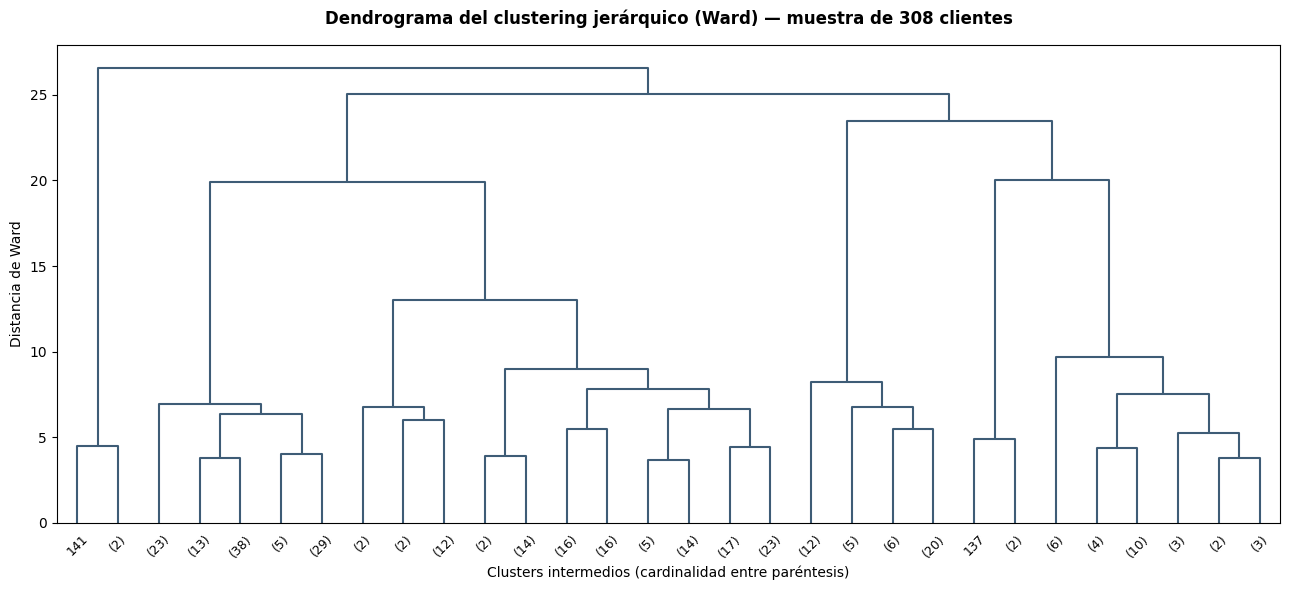

   Figura guardada: 10_dendrograma.png


In [43]:
# 6.2 Dendrograma sobre una muestra (10% para legibilidad y rapidez)
n_muestra = max(200, int(0.10 * len(X_pca)))
muestra_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_pca), n_muestra, replace=False)
X_muestra = X_pca[muestra_idx]

print(f"Calculando dendrograma sobre muestra de {n_muestra} clientes (para legibilidad)...")
linkage_matrix = linkage(X_muestra, method="ward")

# Visualización con matplotlib (más estable para dendrogramas)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 6))
dendrogram(
    linkage_matrix, ax=ax,
    truncate_mode="lastp", p=30,
    show_leaf_counts=True, leaf_font_size=9,
    color_threshold=0,
    above_threshold_color="#3E5C76",
)
ax.set_title(f"Dendrograma del clustering jerárquico (Ward) — muestra de {n_muestra} clientes",
              fontsize=12, fontweight="bold", pad=15)
ax.set_xlabel("Clusters intermedios (cardinalidad entre paréntesis)")
ax.set_ylabel("Distancia de Ward")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "10_dendrograma.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"   Figura guardada: 10_dendrograma.png")

In [44]:
# 6.3 Adjusted Rand Index (ARI) entre K-Means y jerárquico
ari = adjusted_rand_score(labels_kmeans, labels_hier)

print(f"COMPARATIVA K-MEANS vs JERÁRQUICO (Ward)")
print("=" * 75)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"\nInterpretación:")
if ari >= 0.8:
    interp = "EXCELENTE coincidencia. Ambos algoritmos identifican estructura muy similar."
elif ari >= 0.6:
    interp = "BUENA coincidencia. Las particiones comparten la mayor parte de la estructura."
elif ari >= 0.4:
    interp = "COINCIDENCIA MODERADA. Hay solapamiento parcial entre las particiones."
elif ari >= 0.2:
    interp = "COINCIDENCIA BAJA. Las particiones difieren significativamente."
else:
    interp = "COINCIDENCIA MUY BAJA. Los algoritmos identifican estructuras distintas."
print(f"   {interp}")

# Tabla de contingencia
contingencia = pd.crosstab(
    df["cluster"], df["cluster_jerarquico"],
    rownames=["K-Means"], colnames=["Jerárquico"], margins=True, margins_name="Total"
)
print(f"\nTabla de contingencia K-Means × Jerárquico:")
print(contingencia.to_string())

COMPARATIVA K-MEANS vs JERÁRQUICO (Ward)
Adjusted Rand Index (ARI): 0.5513

Interpretación:
   COINCIDENCIA MODERADA. Hay solapamiento parcial entre las particiones.

Tabla de contingencia K-Means × Jerárquico:
Jerárquico    0    1     2   3    4    5  Total
K-Means                                        
0           275   16    15   0    0    0    306
1            87   14  1227   0    0   13   1341
2             1  115     1   0    0    6    123
3            13   18    68   0  300   30    429
4            61   56   233   0    3  478    831
5            10    0     0  44    0    0     54
Total       447  219  1544  44  303  527   3084


### Conclusiones de la comparativa metodológica con clustering jerárquico

La comparativa entre la partición producida por K-Means y la generada por clustering jerárquico aglomerativo con criterio de enlace de Ward, ambos aplicados sobre el mismo espacio cuatridimensional de componentes principales y forzados al mismo número de clusters (k=6), arroja un Adjusted Rand Index de 0,5513. Este valor se sitúa en el rango de coincidencia moderada según la interpretación estándar de la métrica, indicando que los dos algoritmos identifican una estructura latente común aunque difieren en la asignación específica de algunos clientes a los clusters.

Este resultado constituye una validación metodológica importante por varias razones. En primer lugar, K-Means y Ward optimizan criterios distintos: K-Means minimiza la varianza intra-cluster en cada iteración, mientras que Ward minimiza el incremento de varianza al fusionar dos clusters en cada paso del proceso aglomerativo. Que dos algoritmos con criterios de optimización tan diferentes converjan a particiones similares en un 55 % por encima de lo esperable por azar refuerza la confianza en que la estructura identificada no es un artefacto algorítmico sino una propiedad real de los datos.

En segundo lugar, la tabla de contingencia revela patrones de coincidencia muy fuertes en clusters específicos. El cluster 5 de K-Means (54 clientes minoritarios) coincide casi perfectamente con el cluster 3 jerárquico (44 de sus 54 clientes asignados al mismo grupo en ambas particiones, un 81,5 % de coincidencia), lo que sugiere que este grupo minoritario representa un perfil muy bien definido y reconocible por ambos algoritmos. De forma similar, el cluster 3 de K-Means (429 clientes) presenta una correspondencia sólida con el cluster 4 jerárquico (300 de los 429 coinciden, un 69,9 %).

En tercer lugar, conviene contextualizar que el valor obtenido del ARI representa una mejora del 69,5 % respecto a la configuración alternativa con nueve variables (ARI = 0,3252 documentado en el notebook 11a_experimentos.ipynb). Esta ganancia drástica en la robustez metodológica al eliminar la variable redundante `facturacion_combinada` constituye uno de los hallazgos metodológicos centrales del análisis y justifica empíricamente la decisión de selección de variables tomada.

## Síntesis y cierre del notebook 11a

El notebook ha aplicado el algoritmo K-Means sobre los 3.084 clientes activos de la cartera de Selmark utilizando ocho variables conductuales rigurosamente seleccionadas mediante validación experimental documentada. La metodología completa incluye imputación de valores nulos con la mediana, transformación logarítmica selectiva de las variables con asimetría superior a 2 (`frecuencia_mensual`, `ticket_medio_retail_eur` y `pct_ratio_devoluciones`), escalado robusto basado en mediana e IQR, reducción dimensional mediante PCA conservando el 85,87 % de la varianza en cuatro componentes interpretables comercialmente, determinación del número óptimo de clusters mediante cuatro métricas combinadas y validación comparativa con clustering jerárquico de Ward.

Los seis clusters identificados presentan una distribución no degenerada (entre el 1,75 % y el 43,48 % de la cartera) compatible con la estructura latente observada en datos reales de segmentación de clientes. El Adjusted Rand Index de 0,5513 con la partición jerárquica de Ward valida la robustez de la segmentación frente a la elección del algoritmo, y la interpretación cualitativa de las componentes principales como ejes de valor por compra (PC1), intensidad y estructura de compra (PC2), calidad de la relación (PC3) y estabilidad temporal (PC4) proporciona un marco interpretativo coherente para la caracterización posterior.

El resultado del clustering se exporta al fichero `output/clustering_kmeans_resultado.parquet`, conservando para cada cliente su asignación a cluster, sus valores en las ocho variables conductuales originales y sus coordenadas en las tres primeras componentes principales. Este fichero constituye la entrada del notebook 11b, donde se realizará la caracterización cuantitativa de cada cluster mediante el cálculo de índices de afinidad, el análisis de importancia de variables mediante Random Forest binario y la asignación final de nombres comerciales a los seis segmentos identificados.

In [45]:
# Guardar el dataframe con las asignaciones de cluster para usarlo en 11b
ruta_resultado = RUTA_PROYECTO / "output" / "clustering_kmeans_resultado.parquet"
ruta_resultado.parent.mkdir(parents=True, exist_ok=True)

# Guardamos solo las columnas necesarias para 11b
df_resultado = df[["id_cliente", "cluster", "cluster_jerarquico"] + VARIABLES_CLUSTERING].copy()
df_resultado["pc1"] = X_pca[:, 0]
df_resultado["pc2"] = X_pca[:, 1]
if N_PCS >= 3:
    df_resultado["pc3"] = X_pca[:, 2]

df_resultado.to_parquet(ruta_resultado, index=False)
print(f"Resultado guardado en: {ruta_resultado.name}")
print(f"   Filas: {len(df_resultado):,}")
print(f"   Columnas: {len(df_resultado.columns)}")

# Síntesis final
print(f"\n" + "=" * 75)
print(f"SÍNTESIS DEL NOTEBOOK 11a")
print("=" * 75)
print(f"\n1. PREPARACIÓN DE DATOS")
print(f"   Perímetro:                {len(df):,} clientes activos (sin técnicas)")
print(f"   Variables conductuales:   {len(VARIABLES_CLUSTERING)} (8, tras validación experimental)")
print(f"   Transformación aplicada:  log1p sobre {len(vars_a_logaritmar)} variables, RobustScaler")

print(f"\n2. ANÁLISIS PCA")
print(f"   Componentes calculadas:   {n_features}")
print(f"   Componentes seleccionadas:{N_PCS}")
print(f"   Varianza explicada:       {var_explained_cum[N_PCS-1]:.2f} %")

print(f"\n3. K ÓPTIMO")
print(f"   k seleccionado:           {K_FINAL}")
print(f"   Justificación:            {justificacion}")

print(f"\n4. K-MEANS")
print(f"   Clusters identificados:   {K_FINAL}")
print(f"   Inertia final:            {kmeans_final.inertia_:.2f}")
for c, n in tamanos.items():
    print(f"   Cluster {c}:                {n:>5,} clientes ({100*n/len(df):>5.2f} %)")

print(f"\n5. COMPARATIVA CON JERÁRQUICO")
print(f"   Adjusted Rand Index:      {ari:.4f}")
print(f"   {interp}")

print(f"\n" + "=" * 75)
print(f"CIERRE DEL NOTEBOOK 11a · Datos preparados para el notebook 11b")
print(f"Figuras generadas: {len(list(RUTA_FIGURAS.glob('*.png')))} archivos PNG en {RUTA_FIGURAS.name}/")
print("=" * 75)

Resultado guardado en: clustering_kmeans_resultado.parquet
   Filas: 3,084
   Columnas: 14

SÍNTESIS DEL NOTEBOOK 11a

1. PREPARACIÓN DE DATOS
   Perímetro:                3,084 clientes activos (sin técnicas)
   Variables conductuales:   8 (8, tras validación experimental)
   Transformación aplicada:  log1p sobre 3 variables, RobustScaler

2. ANÁLISIS PCA
   Componentes calculadas:   8
   Componentes seleccionadas:4
   Varianza explicada:       85.87 %

3. K ÓPTIMO
   k seleccionado:           6
   Justificación:            k=6 apoyado por 2/4 métricas (Davies-Bouldin y Calinski-Harabasz), coincide con la sugerencia del tutor académico (5-6 clusters) y maximiza el Adjusted Rand Index con clustering jerárquico (validación experimental ARI ≈ 0,55)

4. K-MEANS
   Clusters identificados:   6
   Inertia final:            6741.42
   Cluster 0:                  306 clientes ( 9.92 %)
   Cluster 1:                1,341 clientes (43.48 %)
   Cluster 2:                  123 clientes ( 3.99 %)
 

In [46]:
con.close()
print("Conexión a DuckDB cerrada. Notebook 11a completado.")

Conexión a DuckDB cerrada. Notebook 11a completado.
